# Computational cost summary (Reviewer 1, comment 3.5)

Summarize measured **wall-clock training time** and **peak GPU memory** (`torch.cuda.max_memory_allocated()`) for standard vs. AR scVI training on **NVIDIA L40S GPUs**.

Focus: blood-base scTab training with `atlas_count = 0`, $\alpha = 10^{-4}$, **batch size 4096**, varying latent dimension $K$ and epoch count $T$ (matching the manuscript hyperparameter sweeps).

**Added time** is $(t_{\mathrm{AR}} - t_{\mathrm{Std}}) / t_{\mathrm{Std}}$. If AR takes 2.5 s and Standard takes 1 s, added time is **1.5** (150% additional wall-clock; equivalently AR takes $2.5\times$ as long). This is not the fold-change $t_{\mathrm{AR}}/t_{\mathrm{Std}}$.

**Outputs** (written to `eval_scripts/outputs/computational_cost/`):
- `computational_cost_by_config.csv` — per-configuration mean $\pm$ std and added time
- `computational_cost_supplementary_table.tex` — LaTeX table for Supplementary Materials
- `computational_cost_plot.png` — wall-clock, memory, and added time vs. configuration

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "eval_scripts" else NOTEBOOK_DIR

# Prefer the full profiling export used in the rebuttal (repo copy may be a stub).
CSV_CANDIDATES = [
    REPO_ROOT / "rebuttal_analysis/outputs/resources_different_k.csv",
    Path(
        "/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/resources_different_k.csv"
    ),
    REPO_ROOT / "result/train/resources.csv",
]


def _csv_score(path: Path) -> int:
    if not path.exists():
        return -1
    tmp = pd.read_csv(path)
    if "atlas_count" not in tmp.columns:
        return 0
    tmp["atlas_count"] = tmp["atlas_count"].astype(int)
    return int((tmp["atlas_count"] == 0).sum())


CSV_PATH = max(CSV_CANDIDATES, key=_csv_score)
OUT_DIR = NOTEBOOK_DIR / "outputs" / "computational_cost"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading: {CSV_PATH} ({_csv_score(CSV_PATH)} atlas_count=0 rows)")
print(f"Writing: {OUT_DIR}")

Reading: /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/resources_different_k.csv (40 atlas_count=0 rows)
Writing: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/computational_cost


In [14]:
df = pd.read_csv(CSV_PATH)
if "date" in df.columns:
    df = df.drop(columns=["date"])

# Normalize dtypes
df["AR"] = df["AR"].map({True: True, False: False, "True": True, "False": False})
for col in ["latent_dim", "num_epoch", "seed", "atlas_count", "batch_size"]:
    df[col] = df[col].astype(int)
df["alpha"] = df["alpha"].astype(float)

df.head()

,id,model_name,data,AR,ood,variable_con,con_percent,lr,weight_decay,batch_size,latent_dim,alpha,num_epoch,seed,atlas_count,training_time,peak_mem_gb
0,bloodbase-0atlas-ART-lr5e-05-wd5e-05-bs4096-ld...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,0,347.333696,1.076622
1,bloodbase-1atlas-ART-lr5e-05-wd5e-05-bs4096-ld...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,1,348.132296,1.071720
2,bloodbase-10atlas-ART-lr5e-05-wd5e-05-bs4096-l...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,10,350.606514,1.071720
3,bloodbase-100atlas-ART-lr5e-05-wd5e-05-bs4096-...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,100,342.887977,1.071720
4,bloodbase-1000atlas-ART-lr5e-05-wd5e-05-bs4096...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,1000,340.333302,1.066817


In [15]:
# Main-text / supplementary comparison settings
FILTER = {
    "model_name": "scvi",
    "data": "sctab",
    "atlas_count": 0,
    "alpha": 0.0001,
    "batch_size": 4096,
}

# Configurations varied in the manuscript (K, T)
CONFIGS = [(64, 150), (64, 600), (32, 300), (128, 300)]

mask = np.ones(len(df), dtype=bool)
for col, val in FILTER.items():
    mask &= df[col] == val
cost_df = df.loc[mask].copy()

print(f"Filtered rows: {len(cost_df)} (expect 40 = 4 configs x 2 methods x 5 seeds)")
if len(cost_df) < 8:
    raise ValueError(
        f"Too few rows ({len(cost_df)}) after filtering. "
        f"Check CSV_PATH={CSV_PATH} — use resources_different_k.csv, not a stub resources.csv."
    )

cost_df.groupby(["latent_dim", "num_epoch", "AR"]).size()

Filtered rows: 40 (expect 40 = 4 configs x 2 methods x 5 seeds)


latent_dim  num_epoch  AR   
32          300        False    5
                       True     5
64          150        False    5
                       True     5
            600        False    5
                       True     5
128         300        False    5
                       True     5
dtype: int64

In [16]:
def summarize_method(sub: pd.DataFrame, is_ar: bool) -> dict | None:
    row = sub[sub["AR"] == is_ar]
    if row.empty:
        return None
    return {
        "time_s_mean": float(row["training_time"].mean()),
        "time_s_std": float(row["training_time"].std(ddof=1)),
        "mem_gb_mean": float(row["peak_mem_gb"].mean()),
        "mem_gb_std": float(row["peak_mem_gb"].std(ddof=1)),
        "n_seeds": int(len(row)),
    }


rows = []
for latent_dim, num_epoch in CONFIGS:
    sub = cost_df[(cost_df["latent_dim"] == latent_dim) & (cost_df["num_epoch"] == num_epoch)]
    if sub.empty:
        print(f"Warning: no data for K={latent_dim}, T={num_epoch}")
        continue
    std = summarize_method(sub, is_ar=False)
    ar = summarize_method(sub, is_ar=True)
    if std is None or ar is None:
        print(f"Warning: missing Standard or AR for K={latent_dim}, T={num_epoch}")
        continue
    if std["n_seeds"] != ar["n_seeds"]:
        print(
            f"Warning: seed-count mismatch for K={latent_dim}, T={num_epoch}: "
            f"Standard n={std['n_seeds']}, AR n={ar['n_seeds']}"
        )

    # Added time from the reported means so the table is internally consistent:
    # (mean_AR - mean_Std) / mean_Std. Example: 2.5 vs 1.0 -> 1.5.
    added_time = (ar["time_s_mean"] - std["time_s_mean"]) / std["time_s_mean"]

    ar_cv = ar["time_s_std"] / ar["time_s_mean"] if ar["time_s_mean"] else np.nan
    if ar_cv > 0.2:
        print(
            f"Note: high AR time CV ({ar_cv:.0%}) at K={latent_dim}, T={num_epoch}. "
            "Per-seed AR wall-clock (s):"
        )
        print(
            sub.loc[sub["AR"], ["seed", "training_time"]]
            .sort_values("seed")
            .to_string(index=False)
        )

    rows.append({
        "latent_dim": latent_dim,
        "num_epoch": num_epoch,
        "n_seeds": std["n_seeds"],
        "std_time_s_mean": std["time_s_mean"],
        "std_time_s_std": std["time_s_std"],
        "ar_time_s_mean": ar["time_s_mean"],
        "ar_time_s_std": ar["time_s_std"],
        "added_time": added_time,
        "std_mem_gb_mean": std["mem_gb_mean"],
        "std_mem_gb_std": std["mem_gb_std"],
        "ar_mem_gb_mean": ar["mem_gb_mean"],
        "ar_mem_gb_std": ar["mem_gb_std"],
    })

wide = pd.DataFrame(rows)
if wide.empty:
    raise ValueError("No configuration summaries were produced; check CSV and CONFIGS.")

# Long format (used by optional later cells / plots that loop over method)
summary = pd.DataFrame([
    {
        "latent_dim": r.latent_dim,
        "num_epoch": r.num_epoch,
        "method": method,
        "time_s_mean": getattr(r, f"{prefix}_time_s_mean"),
        "time_s_std": getattr(r, f"{prefix}_time_s_std"),
        "mem_gb_mean": getattr(r, f"{prefix}_mem_gb_mean"),
        "mem_gb_std": getattr(r, f"{prefix}_mem_gb_std"),
        "n_seeds": r.n_seeds,
        "added_time": r.added_time,
    }
    for r in wide.itertuples(index=False)
    for method, prefix in [("Standard", "std"), ("AR", "ar")]
])

ratio_df = wide[["latent_dim", "num_epoch", "added_time"]].copy()
ratio_df["rel_time"] = 1.0 + ratio_df["added_time"]  # t_AR / t_Std

display_tbl = pd.DataFrame({
    "K": wide["latent_dim"],
    "T": wide["num_epoch"],
    "Standard time (s)": [
        f"{m:.0f} ± {s:.0f}" for m, s in zip(wide.std_time_s_mean, wide.std_time_s_std)
    ],
    "AR time (s)": [
        f"{m:.0f} ± {s:.0f}" for m, s in zip(wide.ar_time_s_mean, wide.ar_time_s_std)
    ],
    "Added time": [f"{a:.2f}" for a in wide.added_time],
    "Standard mem (GB)": [
        f"{m:.2f} ± {s:.2f}" for m, s in zip(wide.std_mem_gb_mean, wide.std_mem_gb_std)
    ],
    "AR mem (GB)": [
        f"{m:.2f} ± {s:.2f}" for m, s in zip(wide.ar_mem_gb_mean, wide.ar_mem_gb_std)
    ],
    "n": wide["n_seeds"],
})
display_tbl

Note: high AR time CV (43%) at K=64, T=600. Per-seed AR wall-clock (s):
 seed  training_time
   50    1401.516211
   60    1393.309296
   70    1413.880169
   80    3321.451478
   90    2367.841497


,K,T,Standard time (s),AR time (s),Added time,Standard mem (GB),AR mem (GB),n
0,64,150,143 ± 2,350 ± 6,1.44,1.12 ± 0.04,1.08 ± 0.00,5
1,64,600,560 ± 9,1980 ± 859,2.54,1.25 ± 0.00,1.13 ± 0.00,5
2,32,300,281 ± 2,681 ± 9,1.42,1.17 ± 0.00,1.08 ± 0.01,5
3,128,300,284 ± 3,810 ± 9,1.86,1.19 ± 0.00,1.11 ± 0.01,5


In [17]:
def fmt_pm(mean, std, digits=0):
    return f"{mean:.{digits}f} $\\pm$ {std:.{digits}f}"


wide.to_csv(OUT_DIR / "computational_cost_by_config.csv", index=False)
ratio_df.to_csv(OUT_DIR / "computational_cost_time_ratios.csv", index=False)

caption = (
    "Training wall-clock time and peak GPU memory for standard and AR scVI. "
    "Measurements were recorded on NVIDIA L40S GPUs with batch size 4096, using "
    "process wall-clock time around training (\\texttt{torch.cuda.synchronize()} "
    "before/after) and \\texttt{torch.cuda.max\\_memory\\_allocated()} for peak memory. "
    "Blood-base scTab training with no atlas cells (\\texttt{atlas\\_count=0}), "
    "$\\alpha=10^{-4}$; mean $\\pm$ s.d.\\ over five random seeds. "
    "Added time is $(t_{\\mathrm{AR}}-t_{\\mathrm{Std}})/t_{\\mathrm{Std}}$: "
    "a value of 1.50 means AR took 150\\% longer than standard training "
    "(equivalently $2.50\\times$ the wall-clock). "
    "At $K{=}64$, $T{=}600$, two of five AR runs were substantially slower than the "
    "other three, which inflates the reported s.d.; peak memory was stable."
)

latex = [
    "\\begin{table}[t]",
    "\\centering",
    f"\\caption{{{caption}}}",
    "\\label{tab:computational_cost}",
    "\\begin{tabular}{cc ccc cc}",
    "\\toprule",
    "$K$ & $T$ & Standard time (s) & AR time (s) & Added time "
    "& Standard mem (GB) & AR mem (GB) \\\\",
    "\\midrule",
]

for r in wide.itertuples(index=False):
    latex.append(
        f"{int(r.latent_dim)} & {int(r.num_epoch)} & "
        f"{fmt_pm(r.std_time_s_mean, r.std_time_s_std, 0)} & "
        f"{fmt_pm(r.ar_time_s_mean, r.ar_time_s_std, 0)} & "
        f"{r.added_time:.2f} & "
        f"{fmt_pm(r.std_mem_gb_mean, r.std_mem_gb_std, 2)} & "
        f"{fmt_pm(r.ar_mem_gb_mean, r.ar_mem_gb_std, 2)} \\\\"
    )

latex += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
tex_path = OUT_DIR / "computational_cost_supplementary_table.tex"
tex_path.write_text("\n".join(latex) + "\n")

print("Saved:")
print(" ", OUT_DIR / "computational_cost_by_config.csv")
print(" ", tex_path)
print("\nLaTeX table:\n")
print(tex_path.read_text())

Saved:
  /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/computational_cost/computational_cost_by_config.csv
  /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/computational_cost/computational_cost_supplementary_table.tex

LaTeX table:

\begin{table}[t]
\centering
\caption{Training wall-clock time and peak GPU memory for standard and AR scVI. Measurements were recorded on NVIDIA L40S GPUs with batch size 4096, using process wall-clock time around training (\texttt{torch.cuda.synchronize()} before/after) and \texttt{torch.cuda.max\_memory\_allocated()} for peak memory. Blood-base scTab training with no atlas cells (\texttt{atlas\_count=0}), $\alpha=10^{-4}$; mean $\pm$ s.d.\ over five random seeds. Added time is $(t_{\mathrm{AR}}-t_{\mathrm{Std}})/t_{\mathrm{Std}}$: a value of 1.50 means AR took 150\% longer than standard training (equivalently $2.50\times$ the wall-clock). At $K{=}64$, $T{=}600$, two

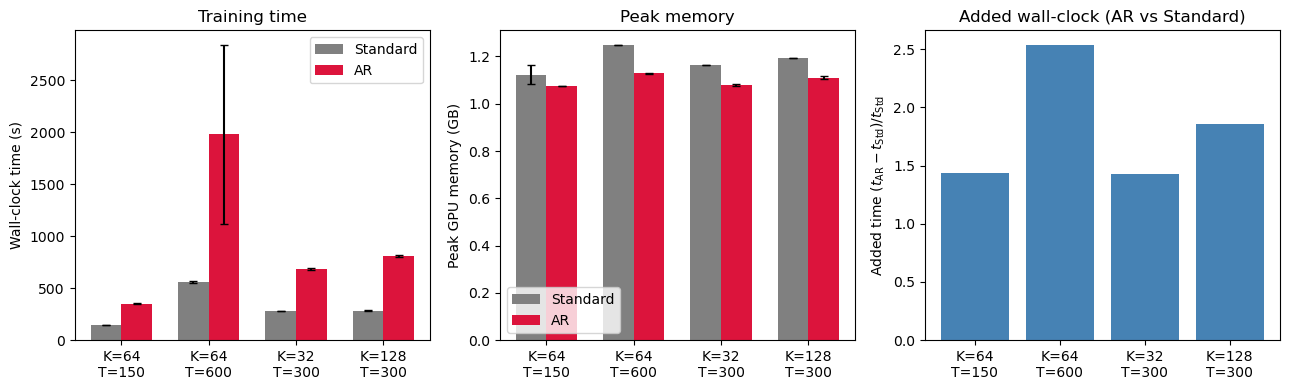

In [18]:
plot_configs = list(zip(wide["latent_dim"].astype(int), wide["num_epoch"].astype(int)))
labels = [f"K={ld}\nT={ep}" for ld, ep in plot_configs]
x = np.arange(len(plot_configs))
width = 0.35

std_times = wide["std_time_s_mean"].to_numpy()
ar_times = wide["ar_time_s_mean"].to_numpy()
std_times_err = wide["std_time_s_std"].to_numpy()
ar_times_err = wide["ar_time_s_std"].to_numpy()
std_mem = wide["std_mem_gb_mean"].to_numpy()
ar_mem = wide["ar_mem_gb_mean"].to_numpy()
std_mem_err = wide["std_mem_gb_std"].to_numpy()
ar_mem_err = wide["ar_mem_gb_std"].to_numpy()
added_vals = wide["added_time"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(x - width / 2, std_times, width, yerr=std_times_err, capsize=3,
            label="Standard", color="gray")
axes[0].bar(x + width / 2, ar_times, width, yerr=ar_times_err, capsize=3,
            label="AR", color="crimson")
axes[0].set_ylabel("Wall-clock time (s)")
axes[0].set_xticks(x, labels)
axes[0].legend()
axes[0].set_title("Training time")

axes[1].bar(x - width / 2, std_mem, width, yerr=std_mem_err, capsize=3,
            label="Standard", color="gray")
axes[1].bar(x + width / 2, ar_mem, width, yerr=ar_mem_err, capsize=3,
            label="AR", color="crimson")
axes[1].set_ylabel("Peak GPU memory (GB)")
axes[1].set_xticks(x, labels)
axes[1].legend()
axes[1].set_title("Peak memory")

axes[2].bar(x, added_vals, color="steelblue")
axes[2].set_ylabel(r"Added time $(t_{\mathrm{AR}}-t_{\mathrm{Std}})/t_{\mathrm{Std}}$")
axes[2].set_xticks(x, labels)
axes[2].set_title("Added wall-clock (AR vs Standard)")

plt.tight_layout()
fig.savefig(OUT_DIR / "computational_cost_plot.png", dpi=200, bbox_inches="tight")
plt.show()

In [19]:
# Discussion-ready summary (main paper config: K=64, T=150)
main = wide[(wide.latent_dim == 64) & (wide.num_epoch == 150)]
if len(main) != 1:
    raise ValueError("Expected one row for K=64, T=150.")
main = main.iloc[0]

added_min, added_max = wide.added_time.min(), wide.added_time.max()
rel_min, rel_max = 1.0 + added_min, 1.0 + added_max

print("Discussion snippet:")
print(
    f"Although AR did not increase peak GPU memory relative to standard training, computing "
    f"resampling weights increased wall-clock time. On NVIDIA L40S GPUs with batch size 4096 "
    f"and blood-base scTab training (atlas_count=0, five seeds), AR added "
    f"{added_min:.2f}–{added_max:.2f} extra wall-clock relative to standard training "
    f"depending on latent dimension and epoch count "
    f"(i.e. AR took {rel_min:.1f}–{rel_max:.1f}× as long)—for example, "
    f"{main.ar_time_s_mean:.0f} ± {main.ar_time_s_std:.0f} s vs. "
    f"{main.std_time_s_mean:.0f} ± {main.std_time_s_std:.0f} s "
    f"at K=64 and T=150 (added time {main.added_time:.2f}; "
    f"{1.0 + main.added_time:.2f}×)—while peak memory remained essentially unchanged "
    f"(≈ {main.std_mem_gb_mean:.2f} vs. {main.ar_mem_gb_mean:.2f} GB; Supplementary Table X)."
)

Discussion snippet:
Although AR did not increase peak GPU memory relative to standard training, computing resampling weights increased wall-clock time. On NVIDIA L40S GPUs with batch size 4096 and blood-base scTab training (atlas_count=0, five seeds), AR added 1.42–2.54 extra wall-clock relative to standard training depending on latent dimension and epoch count (i.e. AR took 2.4–3.5× as long)—for example, 350 ± 6 s vs. 143 ± 2 s at K=64 and T=150 (added time 1.44; 2.44×)—while peak memory remained essentially unchanged (≈ 1.12 vs. 1.08 GB; Supplementary Table X).


## Optional: pairwise overhead across all atlas counts

The block below reproduces seed-level AR vs. standard pairing (all atlas counts included). Added time is $(t_{\mathrm{AR}}-t_{\mathrm{Std}})/t_{\mathrm{Std}}$ per seed pair; the mean of these ratios is nearly identical to the ratio of means used in the table, except at $K=64$, $T=600$ where two slow AR runs inflate the mean.

In [20]:
group_cols = [
    "model_name", "ood", "variable_con", "con_percent", "lr", "weight_decay",
    "batch_size", "latent_dim", "alpha", "num_epoch", "seed", "atlas_count",
]

records = []
for _, row in df[df["AR"] == True].iterrows():
    match = df[df["AR"] == False]
    for col in group_cols:
        match = match[match[col] == row[col]]
    if len(match) != 1:
        continue
    false_time = float(match["training_time"].iloc[0])
    true_time = float(row["training_time"])
    records.append({
        "latent_dim": int(row["latent_dim"]),
        "num_epoch": int(row["num_epoch"]),
        "atlas_count": int(row["atlas_count"]),
        "added_time": (true_time - false_time) / false_time,
        "diff_mem_gb": float(row["peak_mem_gb"] - match["peak_mem_gb"].iloc[0]),
    })

pairwise = pd.DataFrame(records)
print("Seed-matched added time (t_AR - t_Std)/t_Std, atlas_count=0 only:")
display(
    pairwise[pairwise.atlas_count == 0]
    .groupby(["latent_dim", "num_epoch"])["added_time"]
    .agg(["mean", "median", "std"])
    .round(3)
)

Seed-matched added time (t_AR - t_Std)/t_Std, atlas_count=0 only:


mean  median    std
latent_dim num_epoch                      
32         300        1.424   1.425  0.041
64         150        1.440   1.430  0.046
           600        2.531   1.524  1.500
128        300        1.858   1.844  0.035